In [ ]:
!pip install -q timm sentence-transformers albumentations scikit-learn

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import warnings

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import torchvision.transforms as T
import torchvision.models as models

from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
import timm

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

In [ ]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED']       = str(seed)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
from google.colab import files
files.upload()

Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"konerurahul","key":"9b17882bf060acbae463fde37350e139"}'}

In [ ]:
!ls

'kaggle (2).json'   sample_data


In [ ]:
!mkdir -p ~/.kaggle
!cp "kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle (1).json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets list -s fashion-product-text-images-dataset

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
!kaggle datasets download -d nirmalsankalana/fashion-product-text-images-dataset

Dataset URL: https://www.kaggle.com/datasets/nirmalsankalana/fashion-product-text-images-dataset
License(s): MIT
100% 3.17G/3.17G [00:38<00:00, 88.6MB/s]



In [ ]:
!unzip fashion-product-text-images-dataset.zip -d /content/fashion_dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/fashion_dataset/data/58128.jpg  
  inflating: /content/fashion_dataset/data/58129.jpg  
  inflating: /content/fashion_dataset/data/5813.jpg  
  inflating: /content/fashion_dataset/data/58131.jpg  
  inflating: /content/fashion_dataset/data/58132.jpg  
  inflating: /content/fashion_dataset/data/58133.jpg  
  inflating: /content/fashion_dataset/data/58135.jpg  
  inflating: /content/fashion_dataset/data/58136.jpg  
  inflating: /content/fashion_dataset/data/58137.jpg  
  inflating: /content/fashion_dataset/data/58138.jpg  
  inflating: /content/fashion_dataset/data/58139.jpg  
  inflating: /content/fashion_dataset/data/5814.jpg  
  inflating: /content/fashion_dataset/data/58140.jpg  
  inflating: /content/fashion_dataset/data/58141.jpg  
  inflating: /content/fashion_dataset/data/58143.jpg  
  inflating: /content/fashion_dataset/data/58144.jpg  
  inflating: /content/fashion_dataset/data/58145.jpg  
  inflating: /co

In [ ]:
import os

print(os.listdir("/content/fashion_dataset"))

['data', 'data.csv']


In [ ]:
print(len(os.listdir("/content/fashion_dataset/data")))

44441


In [ ]:
CSV_PATH = "/content/fashion_dataset/data.csv"
IMAGE_DIR = "/content/fashion_dataset/data"

LABEL_COL = "category"
TEXT_COL  = "description"
IMG_COL   = "image"

BATCH_SIZE = 32
IMG_SIZE   = 224
MAX_LEN    = 128
EPOCHS     = 3
PROJ_DIM   = 512

FUSION_TYPES = ["Concat", "Addition", "CrossAttention"]
LOSS_TYPES   = ["CrossEntropy", "Contrastive", "JointLoss", "WeightedJoint"]

In [ ]:
df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print("Columns      :", df.columns.tolist())
print("Unique labels:", df[LABEL_COL].nunique())

df.head()

Dataset shape: (44441, 4)
Columns      : ['image', 'description', 'display name', 'category']
Unique labels: 142


,image,description,display name,category
0,3238.jpg,"Round toed, black sports shoes with red accent...",Puma Men Black 65CC Lo Ducati Sports Shoes,Sports Shoes
1,43044.jpg,Style Note Built with the breathability and ze...,Nike Men Charcoal Grey Shorts,Shorts
2,54018.jpg,Teal handbag that has stitch detailing with a...,Kiara Women Teal Handbag,Handbags
3,8141.jpg,"Perfectly stylish, this fastrack analog wrist ...",Fastrack Women Freestyle Sports Analog Steel B...,Watches
4,22245.jpg,These id mid-top chukka shoes add a fresh spin...,ID Men Brown Casual Shoes,Casual Shoes


In [ ]:
# Missing values
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Missing images
import os

missing_images = (~df["image"].apply(lambda x: os.path.exists(os.path.join(IMAGE_DIR, x)))).sum()

print("Missing image files:", missing_images)

image             0
description     281
display name      7
category          0
dtype: int64

Duplicate rows: 0
Missing image files: 0


In [ ]:
df = df.dropna(subset=["description"]).reset_index(drop=True)

In [ ]:
# Number of samples in each class
class_counts = df[LABEL_COL].value_counts()

print("Number of classes:", len(class_counts))

print("\nTop 10 most frequent classes:")
print(class_counts.head(10))

print("\nBottom 10 least frequent classes:")
print(class_counts.tail(10))

print("\nStatistics:")
print(class_counts.describe())

Number of classes: 141

Top 10 most frequent classes:
category
Tshirts         7053
Shirts          3163
Casual Shoes    2841
Watches         2516
Sports Shoes    2035
Kurtas          1842
Tops            1758
Handbags        1753
Heels           1322
Sunglasses      1024
Name: count, dtype: int64

Bottom 10 least frequent classes:
category
Lounge Tshirts        3
Ties and Cufflinks    2
Face Serum and Gel    2
Rain Trousers         2
Key chain             2
Ipad                  1
Cushion Covers        1
Mens Grooming Kit     1
Hair Accessory        1
Shoe Laces            1
Name: count, dtype: int64

Statistics:
count     141.000000
mean      313.191489
std       782.909554
min         1.000000
25%        11.000000
50%        49.000000
75%       263.000000
max      7053.000000
Name: count, dtype: float64


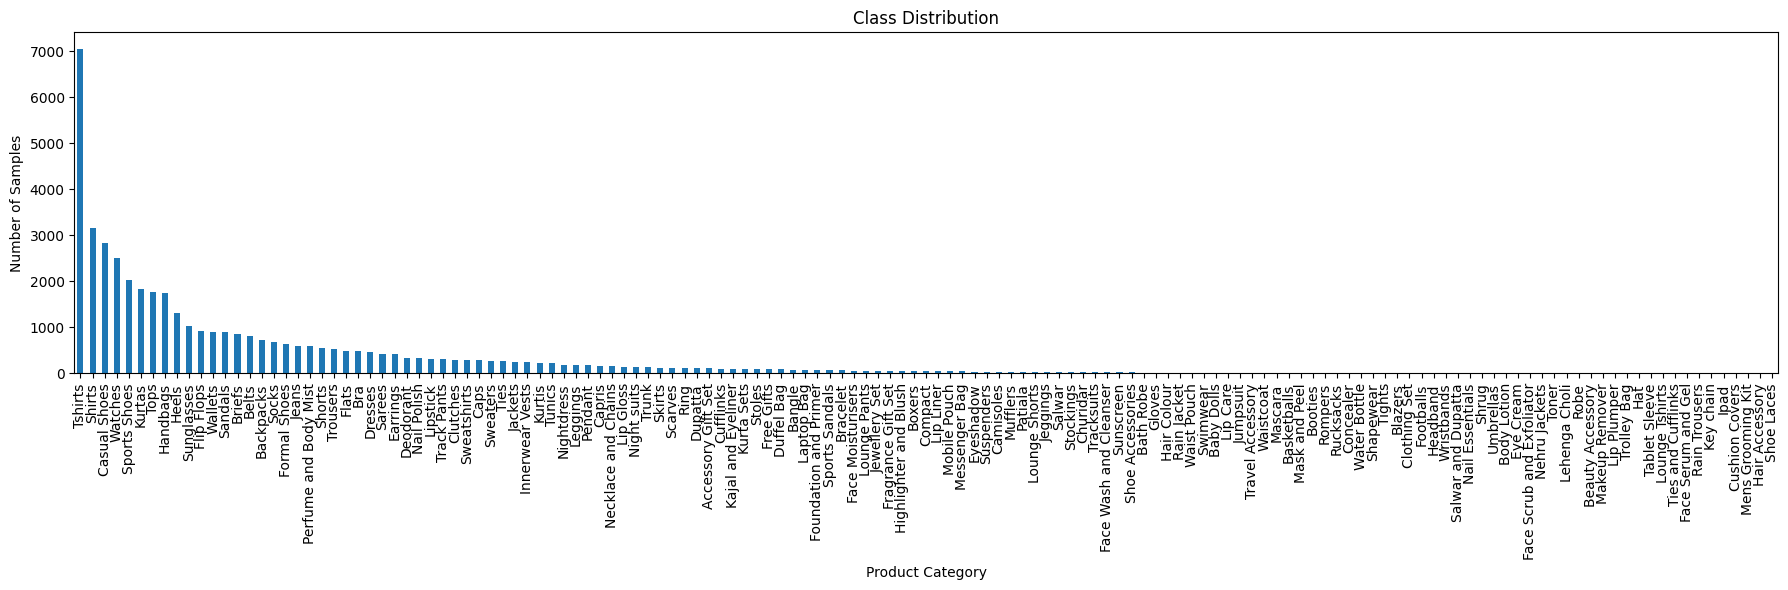

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

class_counts.sort_values(ascending=False).plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Product Category")
plt.ylabel("Number of Samples")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
thresholds = [1, 2, 5, 10, 20, 30, 50]

for t in thresholds:
    num_classes = (class_counts < t).sum()
    print(f"Classes with fewer than {t:2d} samples: {num_classes}")

Classes with fewer than  1 samples: 0
Classes with fewer than  2 samples: 5
Classes with fewer than  5 samples: 18
Classes with fewer than 10 samples: 34
Classes with fewer than 20 samples: 51
Classes with fewer than 30 samples: 57
Classes with fewer than 50 samples: 71


In [ ]:
rare_classes = class_counts[class_counts < 20]

print("Number of rare classes:", len(rare_classes))
print("Total samples in rare classes:", rare_classes.sum())

Number of rare classes: 51
Total samples in rare classes: 398


In [ ]:
# Keep only classes with at least 20 samples
valid_classes = class_counts[class_counts >= 20].index

df = df[df[LABEL_COL].isin(valid_classes)].reset_index(drop=True)

print("New dataset shape:", df.shape)
print("Remaining classes:", df[LABEL_COL].nunique())

New dataset shape: (43762, 4)
Remaining classes: 90


In [ ]:
new_class_counts = df[LABEL_COL].value_counts()

print(new_class_counts.describe())

count      90.000000
mean      486.244444
std       938.320282
min        20.000000
25%        56.500000
50%       152.000000
75%       492.000000
max      7053.000000
Name: count, dtype: float64


In [ ]:
train_df, temp_df = train_test_split(
    df,
    train_size=0.6,
    stratify=df[LABEL_COL],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df[LABEL_COL],
    random_state=SEED
)

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")
print(f"Total : {len(train_df) + len(val_df) + len(test_df)}")

all_labels  = sorted(df[LABEL_COL].unique())
label2id    = {label: i for i, label in enumerate(all_labels)}
id2label    = {i: label for label, i in label2id.items()}
NUM_CLASSES = len(label2id)

print(f"\nTotal classes: {NUM_CLASSES}")

Train : 26257
Val   : 8752
Test  : 8753
Total : 43762

Total classes: 90


In [ ]:
print("Train class distribution:")
print(train_df[LABEL_COL].value_counts().describe())

print("\nValidation class distribution:")
print(val_df[LABEL_COL].value_counts().describe())

print("\nTest class distribution:")
print(test_df[LABEL_COL].value_counts().describe())

Train class distribution:
count      90.000000
mean      291.744444
std       563.035065
min        12.000000
25%        34.250000
50%        91.000000
75%       295.000000
max      4232.000000
Name: count, dtype: float64

Validation class distribution:
count      90.000000
mean       97.244444
std       187.511516
min         4.000000
25%        11.250000
50%        30.500000
75%        98.000000
max      1410.000000
Name: count, dtype: float64

Test class distribution:
count      90.000000
mean       97.255556
std       187.774402
min         4.000000
25%        11.000000
50%        30.500000
75%        99.000000
max      1411.000000
Name: count, dtype: float64


In [ ]:
train_counts = train_df[LABEL_COL].value_counts()

print("Training classes with <20 samples:", (train_counts < 20).sum())
print("Training classes with <30 samples:", (train_counts < 30).sum())
print("Training classes with <50 samples:", (train_counts < 50).sum())



Training classes with <20 samples: 9
Training classes with <30 samples: 20
Training classes with <50 samples: 30


In [ ]:
train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.1, 0.1, 0.1, 0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

val_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

print("Train transforms:", train_tfms)
print("Val   transforms:", val_tfms)

Train transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.9, 1.1), hue=(-0.1, 0.1))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Val   transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
TEXT_MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)


class FashionDataset(Dataset):

    def __init__(self, df, img_dir, tokenizer, label2id,
                 img_tfms=None, max_len=MAX_LEN):

        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.tokenizer = tokenizer
        self.img_tfms  = img_tfms
        self.max_len   = max_len
        self.label2id  = label2id

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # ── Image
        img_path = os.path.join(self.img_dir, row[IMG_COL])
        image = Image.open(img_path).convert("RGB")

        if self.img_tfms:
            image = self.img_tfms(image)

        # ── Text
        text = str(row[TEXT_COL])

        enc = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        # ── Label
        label = self.label2id[row[LABEL_COL]]

        return {
            "image": image,
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long),
            "text": text
        }


train_ds = FashionDataset(
    train_df, IMAGE_DIR, tokenizer, label2id, train_tfms
)

val_ds = FashionDataset(
    val_df, IMAGE_DIR, tokenizer, label2id, val_tfms
)

test_ds = FashionDataset(
    test_df, IMAGE_DIR, tokenizer, label2id, val_tfms
)


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Train batches : 821
Val   batches : 274
Test  batches : 274


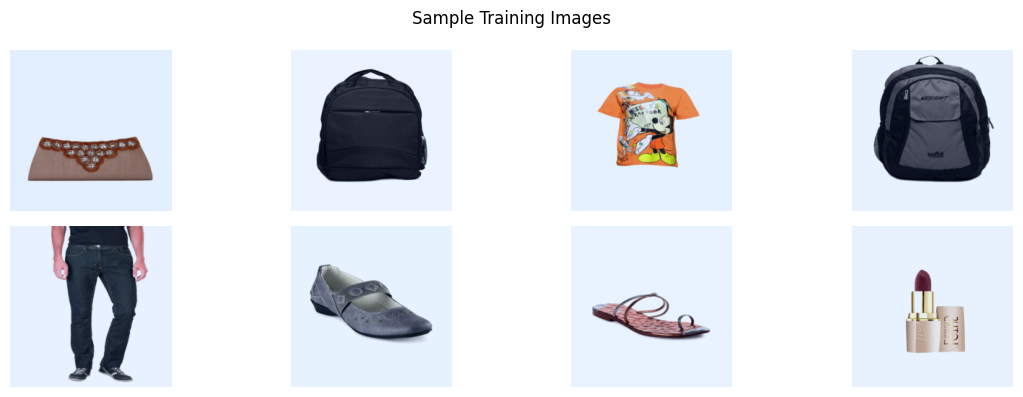

Sample Texts:
1. Look your glamorous best with this spice art clutch, customised for the ethnic diva in you. Show off your traditional side with this piece, which is as functional as it is fashionable.   Width : 27 cm  Height : 12 cm  Made of raw silk with a nylon inner lining Stone embellishments along the top width of the clutch on the front One main compartment with a magnetic clasp A zippered mobile pouch inside the main compartment   Care Wipe surface with a damp clean cloth
2. Crafted for the cosmopolitan male, this bag from cabarelli is made with materials of superior quality. Wear this utilitarian, monochrome bag with formal or casual ensembles, and don't forget to style your outfit with matching accessories.  Length : 44 cm Width : 32 cm Depth : 13 cm  Made of polyester blend fabric Two main zippered compartments Laptop holder with a click lock in the second compartment One zippered and padded compartment on the front with a zippered pocket outside it A mesh pocket on one side

In [ ]:
# ── Get one batch for sanity checking
batch = next(iter(train_loader))

# ── Check images
imgs = batch["image"][:8]

plt.figure(figsize=(12, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    img = imgs[i].permute(1, 2, 0).cpu().numpy()

    # Undo normalization only for visualization
    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()


# ── Check text and labels
print("Sample Texts:")
for i, text in enumerate(batch["text"][:2]):
    print(f"{i+1}. {text}")

print("\nSample Labels:")
print(batch["label"][:8])


# ── Check tensor shapes
print("\n" + "="*50)
print("Batch Tensor Shapes")
print("="*50)

print("Image shape         :", batch["image"].shape)
print("Input IDs shape     :", batch["input_ids"].shape)
print("Attention mask shape:", batch["attention_mask"].shape)
print("Labels shape        :", batch["label"].shape)


# ── Check attention mask
print("\n" + "="*50)
print("Attention Mask Example")
print("="*50)

print(batch["attention_mask"][0])


# ── Check token IDs
print("\n" + "="*50)
print("Input IDs Example")
print("="*50)

print(batch["input_ids"][0])

In [ ]:
scaler = GradScaler()

class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2
        )
        self.backbone.fc = nn.Linear(
            self.backbone.fc.in_features, num_classes
        )
    def forward(self, x):
        return self.backbone(x)


class ViTClassifier(nn.Module):
    def __init__(self, num_classes,
                 model_name="vit_base_patch16_224"):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=True
        )
        self.backbone.head = nn.Linear(
            self.backbone.head.in_features, num_classes
        )
    def forward(self, x):
        return self.backbone(x)

In [ ]:
def train_image_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0
    for batch in tqdm(loader, desc="Train"):
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        optimizer.zero_grad()
        with autocast():
            logits = model(images)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def validate_image(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        with autocast():
            logits = model(images)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def report_image(model, loader, model_type="image"):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        labels = batch["label"].to(device)
        if model_type == "image":
            logits = model(batch["image"].to(device))
        elif model_type == "sbert":
            logits = model(batch["text"])
        else:
            logits = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device)
            )
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    print(classification_report(
        all_labels, all_preds,
        labels=list(range(NUM_CLASSES)),
        target_names=[id2label[i] for i in range(NUM_CLASSES)],
        zero_division=0
    ))

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:


set_seed()
resnet_model = ResNet50Classifier(NUM_CLASSES).to(device)
optimizer    = torch.optim.AdamW(resnet_model.parameters(), lr=3e-4)
resnet_hist  = {"train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_image_one_epoch(
        resnet_model, train_loader, optimizer, criterion
    )
    vl_loss, vl_acc = validate_image(
        resnet_model, val_loader, criterion
    )
    resnet_hist["train_acc"].append(tr_acc)
    resnet_hist["val_acc"].append(vl_acc)
    print(f"[ResNet50] Epoch {epoch+1}/{EPOCHS} "
          f"| Train {tr_acc:.4f} | Val {vl_acc:.4f}")

print("\n--- ResNet50 Classification Report ---")
report_image(resnet_model, val_loader, "image")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 59.0MB/s]
Train: 100%|██████████| 821/821 [08:57<00:00,  1.53it/s]


[ResNet50] Epoch 1/3 | Train 0.7888 | Val 0.8656


Train: 100%|██████████| 821/821 [08:37<00:00,  1.59it/s]


[ResNet50] Epoch 2/3 | Train 0.8777 | Val 0.8729


Train: 100%|██████████| 821/821 [08:27<00:00,  1.62it/s]


[ResNet50] Epoch 3/3 | Train 0.9030 | Val 0.8731

--- ResNet50 Classification Report ---
                        precision    recall  f1-score   support

    Accessory Gift Set       0.96      1.00      0.98        22
             Backpacks       0.97      0.87      0.92       143
                Bangle       0.52      0.65      0.58        17
             Bath Robe       1.00      0.25      0.40         4
                 Belts       0.98      1.00      0.99       162
                Boxers       1.00      0.73      0.84        11
                   Bra       0.97      0.98      0.97        95
              Bracelet       0.60      0.23      0.33        13
                Briefs       0.94      0.96      0.95       169
             Camisoles       0.47      0.88      0.61         8
                Capris       0.79      0.54      0.64        35
                  Caps       1.00      1.00      1.00        56
          Casual Shoes       0.91      0.70      0.79       568
              

In [ ]:
set_seed()
vit_model = ViTClassifier(NUM_CLASSES).to(device)
optimizer = torch.optim.AdamW(vit_model.parameters(), lr=3e-4)
vit_hist  = {"train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_image_one_epoch(
        vit_model, train_loader, optimizer, criterion
    )
    vl_loss, vl_acc = validate_image(
        vit_model, val_loader, criterion
    )
    vit_hist["train_acc"].append(tr_acc)
    vit_hist["val_acc"].append(vl_acc)
    print(f"[ViT] Epoch {epoch+1}/{EPOCHS} "
          f"| Train {tr_acc:.4f} | Val {vl_acc:.4f}")

print("\n--- ViT Classification Report ---")
report_image(vit_model, val_loader, "image")

image_only_results = {
    "ResNet50": max(resnet_hist["val_acc"]),
    "ViT":      max(vit_hist["val_acc"])
}
print("\nImage-only Results:", image_only_results)

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Train: 100%|██████████| 821/821 [10:11<00:00,  1.34it/s]


[ViT] Epoch 1/3 | Train 0.5472 | Val 0.7113


Train: 100%|██████████| 821/821 [09:25<00:00,  1.45it/s]


[ViT] Epoch 2/3 | Train 0.7250 | Val 0.7314


Train: 100%|██████████| 821/821 [09:21<00:00,  1.46it/s]


[ViT] Epoch 3/3 | Train 0.7556 | Val 0.7759

--- ViT Classification Report ---
                        precision    recall  f1-score   support

    Accessory Gift Set       0.90      0.86      0.88        22
             Backpacks       0.86      0.90      0.88       143
                Bangle       0.33      0.29      0.31        17
             Bath Robe       0.00      0.00      0.00         4
                 Belts       0.95      0.97      0.96       162
                Boxers       1.00      0.09      0.17        11
                   Bra       0.82      0.98      0.89        95
              Bracelet       0.33      0.15      0.21        13
                Briefs       0.91      0.92      0.91       169
             Camisoles       0.00      0.00      0.00         8
                Capris       0.56      0.26      0.35        35
                  Caps       0.87      0.73      0.80        56
          Casual Shoes       0.84      0.58      0.69       568
              Churidar  

In [ ]:
class BERTClassifier(nn.Module):
    def __init__(self, num_classes,
                 model_name="bert-base-uncased"):
        super().__init__()
        self.bert    = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.2)
        self.fc      = nn.Linear(
            self.bert.config.hidden_size, num_classes
        )
    def forward(self, input_ids, attention_mask):
        cls = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0]
        return self.fc(self.dropout(cls))


class SBERTClassifier(nn.Module):
    def __init__(self, num_classes,
                 model_name="sentence-transformers/all-MiniLM-L6-v2"):
        super().__init__()
        self.sbert  = SentenceTransformer(model_name)
        emb_dim     = self.sbert.get_sentence_embedding_dimension()
        self.fc     = nn.Sequential(
            nn.Linear(emb_dim, 256), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, texts):
        emb = self.sbert.encode(
            texts, convert_to_tensor=True, device=device
        ).detach().clone().float()          # ← only this line changed
        return self.fc(emb)


class BiGRU_BERT(nn.Module):
    def __init__(self, num_classes,
                 model_name="bert-base-uncased",
                 hidden_size=256):
        super().__init__()
        self.bert    = AutoModel.from_pretrained(model_name)
        self.bigru   = nn.GRU(
            self.bert.config.hidden_size, hidden_size,
            batch_first=True, bidirectional=True
        )
        self.dropout = nn.Dropout(0.2)
        self.fc      = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            seq = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            ).last_hidden_state
        gru_out, _ = self.bigru(seq)
        return self.fc(self.dropout(gru_out.mean(dim=1)))

In [ ]:
def train_text_one_epoch(model, loader, optimizer,
                         criterion, model_type="bert"):
    model.train()
    total_loss = correct = total = 0
    for batch in tqdm(loader, desc="Train"):
        labels = batch["label"].to(device)
        optimizer.zero_grad()
        if model_type == "sbert":
            logits = model(batch["text"])
        else:
            logits = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device)
            )
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def validate_text(model, loader, criterion, model_type="bert"):
    model.eval()
    total_loss = correct = total = 0
    for batch in loader:
        labels = batch["label"].to(device)
        if model_type == "sbert":
            logits = model(batch["text"])
        else:
            logits = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device)
            )
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total

In [ ]:
set_seed()
bert_model = BERTClassifier(NUM_CLASSES).to(device)
optimizer  = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)
bert_hist  = {"train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_text_one_epoch(
        bert_model, train_loader, optimizer, criterion, "bert"
    )
    vl_loss, vl_acc = validate_text(
        bert_model, val_loader, criterion, "bert"
    )
    bert_hist["train_acc"].append(tr_acc)
    bert_hist["val_acc"].append(vl_acc)
    print(f"[BERT] Epoch {epoch+1}/{EPOCHS} "
          f"| Train {tr_acc:.4f} | Val {vl_acc:.4f}")

print("\n--- BERT Classification Report ---")
report_image(bert_model, val_loader, "text")

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Train: 100%|██████████| 821/821 [10:41<00:00,  1.28it/s]


[BERT] Epoch 1/3 | Train 0.7793 | Val 0.8907


Train: 100%|██████████| 821/821 [10:53<00:00,  1.26it/s]


[BERT] Epoch 2/3 | Train 0.9020 | Val 0.9114


Train: 100%|██████████| 821/821 [10:28<00:00,  1.31it/s]


[BERT] Epoch 3/3 | Train 0.9242 | Val 0.9117

--- BERT Classification Report ---
                        precision    recall  f1-score   support

    Accessory Gift Set       1.00      1.00      1.00        22
             Backpacks       0.98      0.94      0.96       143
                Bangle       0.94      0.94      0.94        17
             Bath Robe       1.00      1.00      1.00         4
                 Belts       1.00      0.94      0.97       162
                Boxers       0.92      1.00      0.96        11
                   Bra       1.00      1.00      1.00        95
              Bracelet       0.92      0.92      0.92        13
                Briefs       0.98      0.98      0.98       169
             Camisoles       0.89      1.00      0.94         8
                Capris       0.91      0.86      0.88        35
                  Caps       1.00      0.95      0.97        56
          Casual Shoes       0.68      0.73      0.70       568
              Churidar

In [ ]:
set_seed()
sbert_model = SBERTClassifier(NUM_CLASSES).to(device)
optimizer   = torch.optim.AdamW(
    sbert_model.fc.parameters(), lr=1e-3
)
sbert_hist  = {"train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_text_one_epoch(
        sbert_model, train_loader, optimizer, criterion, "sbert"
    )
    vl_loss, vl_acc = validate_text(
        sbert_model, val_loader, criterion, "sbert"
    )
    sbert_hist["train_acc"].append(tr_acc)
    sbert_hist["val_acc"].append(vl_acc)
    print(f"[SBERT] Epoch {epoch+1}/{EPOCHS} "
          f"| Train {tr_acc:.4f} | Val {vl_acc:.4f}")

print("\n--- SBERT Classification Report ---")
report_image(sbert_model, val_loader, "sbert")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

[SBERT] Epoch 1/3 | Train 0.6414 | Val 0.8110


Train: 100%|██████████| 821/821 [08:30<00:00,  1.61it/s]


[SBERT] Epoch 2/3 | Train 0.8294 | Val 0.8528


Train: 100%|██████████| 821/821 [08:26<00:00,  1.62it/s]


[SBERT] Epoch 3/3 | Train 0.8616 | Val 0.8753

--- SBERT Classification Report ---
                        precision    recall  f1-score   support

    Accessory Gift Set       0.83      0.86      0.84        22
             Backpacks       0.89      0.92      0.90       143
                Bangle       0.94      0.88      0.91        17
             Bath Robe       0.00      0.00      0.00         4
                 Belts       0.99      0.93      0.96       162
                Boxers       1.00      0.64      0.78        11
                   Bra       1.00      1.00      1.00        95
              Bracelet       0.85      0.85      0.85        13
                Briefs       0.92      0.98      0.95       169
             Camisoles       1.00      1.00      1.00         8
                Capris       0.92      0.69      0.79        35
                  Caps       0.98      0.88      0.92        56
          Casual Shoes       0.76      0.80      0.78       568
              Churid

In [ ]:
set_seed()
bigru_model = BiGRU_BERT(NUM_CLASSES).to(device)
optimizer   = torch.optim.AdamW(bigru_model.parameters(), lr=1e-3)
bigru_hist  = {"train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_text_one_epoch(
        bigru_model, train_loader, optimizer, criterion, "bigru"
    )
    vl_loss, vl_acc = validate_text(
        bigru_model, val_loader, criterion, "bigru"
    )
    bigru_hist["train_acc"].append(tr_acc)
    bigru_hist["val_acc"].append(vl_acc)
    print(f"[BiGRU+BERT] Epoch {epoch+1}/{EPOCHS} "
          f"| Train {tr_acc:.4f} | Val {vl_acc:.4f}")

print("\n--- BiGRU+BERT Classification Report ---")
report_image(bigru_model, val_loader, "text")


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Train: 100%|██████████| 821/821 [09:27<00:00,  1.45it/s]


[BiGRU+BERT] Epoch 1/3 | Train 0.7588 | Val 0.8654


Train: 100%|██████████| 821/821 [08:53<00:00,  1.54it/s]


[BiGRU+BERT] Epoch 2/3 | Train 0.8793 | Val 0.8892


Train: 100%|██████████| 821/821 [08:51<00:00,  1.54it/s]


[BiGRU+BERT] Epoch 3/3 | Train 0.9003 | Val 0.9031

--- BiGRU+BERT Classification Report ---
                        precision    recall  f1-score   support

    Accessory Gift Set       1.00      0.95      0.98        22
             Backpacks       0.93      0.96      0.94       143
                Bangle       1.00      0.94      0.97        17
             Bath Robe       0.00      0.00      0.00         4
                 Belts       1.00      0.94      0.97       162
                Boxers       0.92      1.00      0.96        11
                   Bra       1.00      1.00      1.00        95
              Bracelet       0.86      0.92      0.89        13
                Briefs       0.99      0.98      0.99       169
             Camisoles       1.00      1.00      1.00         8
                Capris       0.90      0.80      0.85        35
                  Caps       1.00      0.95      0.97        56
          Casual Shoes       0.79      0.85      0.82       568
          

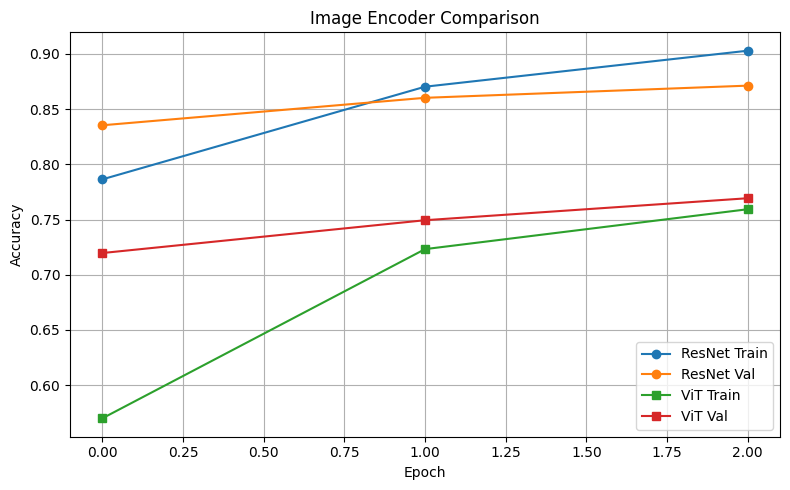

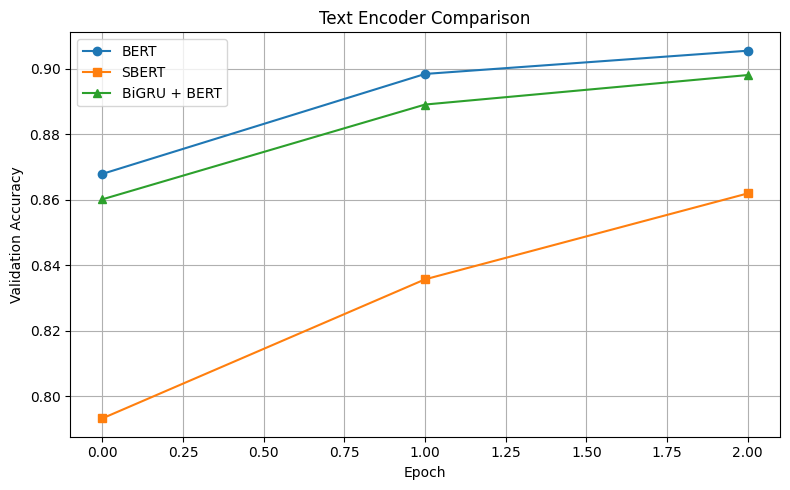

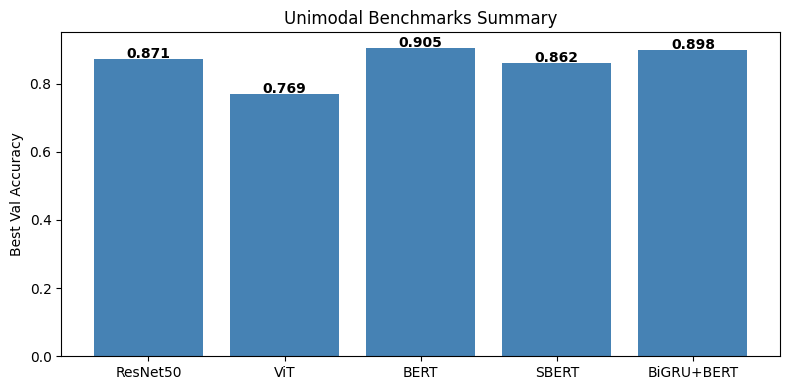

In [ ]:
# ── Image encoders
plt.figure(figsize=(8, 5))
plt.plot(resnet_hist["train_acc"], label="ResNet Train", marker="o")
plt.plot(resnet_hist["val_acc"],   label="ResNet Val",   marker="o")
plt.plot(vit_hist["train_acc"],    label="ViT Train",    marker="s")
plt.plot(vit_hist["val_acc"],      label="ViT Val",      marker="s")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Image Encoder Comparison")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ── Text encoders
plt.figure(figsize=(8, 5))
plt.plot(bert_hist["val_acc"],  label="BERT",         marker="o")
plt.plot(sbert_hist["val_acc"], label="SBERT",        marker="s")
plt.plot(bigru_hist["val_acc"], label="BiGRU + BERT", marker="^")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.title("Text Encoder Comparison")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ── Combined summary bar chart
all_unimodal = {**image_only_results, **text_only_results}
plt.figure(figsize=(8, 4))
plt.bar(all_unimodal.keys(), all_unimodal.values(), color="steelblue")
plt.ylabel("Best Val Accuracy")
plt.title("Unimodal Benchmarks Summary")
for i, (k, v) in enumerate(all_unimodal.items()):
    plt.text(i, v + 0.003, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

In [ ]:
class FusionModel(nn.Module):
    """
    Handles Concat / Addition / CrossAttention in one class.
    freeze_backbones=True  → projection + classifier only  (Blocks 22, 23)
    freeze_backbones=False → entire network trainable       (Block 24)
    """

    def __init__(self, num_classes, fusion_type,
                 proj_dim=PROJ_DIM, num_heads=8,
                 freeze_backbones=True):

        assert fusion_type in FUSION_TYPES, \
            f"fusion_type must be one of {FUSION_TYPES}, got '{fusion_type}'"

        super().__init__()
        self.fusion_type = fusion_type

        # ── Image backbone (always load fresh pretrained)
        self.image_backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2
        )
        self.image_backbone.fc = nn.Identity()

        # ── Text backbone (always load fresh pretrained)
        self.text_backbone = AutoModel.from_pretrained(
            "bert-base-uncased"
        )

        # ── Freeze / unfreeze — explicit single place
        for p in self.image_backbone.parameters():
            p.requires_grad = not freeze_backbones
        for p in self.text_backbone.parameters():
            p.requires_grad = not freeze_backbones

        # ── Projection heads (always trainable)
        self.image_proj = nn.Linear(2048, proj_dim)
        self.text_proj  = nn.Linear(768,  proj_dim)

        # ── Cross-attention (only created when needed)
        if fusion_type == "CrossAttention":
            self.cross_attn = nn.MultiheadAttention(
                embed_dim=proj_dim,
                num_heads=num_heads,
                batch_first=True
            )

        # ── Classifier
        classifier_in = proj_dim * 2 if fusion_type == "Concat" \
                        else proj_dim
        self.classifier = nn.Sequential(
            nn.Linear(classifier_in, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

        # ── Runtime confirmation
        status    = "FROZEN" if freeze_backbones else "TRAINABLE"
        trainable = sum(p.numel() for p in self.parameters()
                        if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f"[FusionModel] fusion={fusion_type} | "
              f"backbones={status} | "
              f"trainable={trainable:,}/{total:,}")

    # ── Internal fusion logic
    def _fuse(self, img_feat, text_feat):
        if self.fusion_type == "Concat":
            return torch.cat([img_feat, text_feat], dim=1)
        elif self.fusion_type == "Addition":
            return img_feat + text_feat
        elif self.fusion_type == "CrossAttention":
            attn_out, _ = self.cross_attn(
                query=img_feat.unsqueeze(1),
                key=text_feat.unsqueeze(1),
                value=text_feat.unsqueeze(1)
            )
            return attn_out.squeeze(1)

    def forward(self, images, input_ids, attention_mask,
                return_embeddings=False):
        img_feat  = self.image_proj(
            self.image_backbone(images)
        )
        cls       = self.text_backbone(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0]
        text_feat = self.text_proj(cls)

        fused  = self._fuse(img_feat, text_feat)
        logits = self.classifier(fused)

        if return_embeddings:
            return (
                logits,
                F.normalize(img_feat,  dim=1),
                F.normalize(text_feat, dim=1)
            )
        return logits

In [ ]:
def train_multimodal_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0
    for batch in tqdm(loader, desc="Train"):
        images         = batch["image"].to(device)
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)
        optimizer.zero_grad()
        logits = model(images, input_ids, attention_mask)
        loss   = criterion(logits, labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def validate_multimodal(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    for batch in loader:
        images         = batch["image"].to(device)
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)
        logits = model(images, input_ids, attention_mask)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def report_fusion(model, loader, name):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        images         = batch["image"].to(device)
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)
        logits = model(images, input_ids, attention_mask)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    print(f"\n{'='*60}")
    print(f" Classification Report — {name}")
    print(f"{'='*60}")
    print(classification_report(
        all_labels, all_preds,
        labels=list(range(NUM_CLASSES)),
        target_names=[id2label[i] for i in range(NUM_CLASSES)],
        zero_division=0
    ))

In [ ]:
criterion      = nn.CrossEntropyLoss()
fusion_results = {}
fusion_models  = {}

for fusion_type in FUSION_TYPES:

    print(f"\n{'='*60}")
    print(f"  Training  →  fusion_type = '{fusion_type}'")
    print(f"{'='*60}")

    set_seed()

    model = FusionModel(
        num_classes=NUM_CLASSES,
        fusion_type=fusion_type,
        proj_dim=PROJ_DIM,
        freeze_backbones=True
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    best_val = 0.0
    best_state = None

    for epoch in range(EPOCHS):

        tr_loss, tr_acc = train_multimodal_one_epoch(
            model, train_loader, optimizer, criterion
        )

        vl_loss, vl_acc = validate_multimodal(
            model, val_loader, criterion
        )

        if vl_acc > best_val:
            best_val = vl_acc
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"  Epoch {epoch+1}/{EPOCHS} "
            f"| Train {tr_acc:.4f} | Val {vl_acc:.4f}"
        )

    # Restore best validation epoch
    model.load_state_dict(best_state)

    fusion_results[fusion_type] = best_val
    fusion_models[fusion_type] = model

    print(f"  Best Val Accuracy: {best_val:.4f}")


  Training  →  fusion_type = 'Concat'
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 99.1MB/s]


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

  Epoch 1/3 | Train 0.5459 | Val 0.7313


Train: 100%|██████████| 821/821 [09:10<00:00,  1.49it/s]


  Epoch 2/3 | Train 0.6448 | Val 0.7234


Train: 100%|██████████| 821/821 [09:10<00:00,  1.49it/s]


  Epoch 3/3 | Train 0.6667 | Val 0.7029
  Best Val Accuracy: 0.7313


In [ ]:
def contrastive_loss(img_feat, text_feat, temperature=0.07):
    logits = img_feat @ text_feat.T / temperature
    labels = torch.arange(
        logits.size(0),
        device=logits.device
    )
    loss_i = F.cross_entropy(logits, labels)
    loss_t = F.cross_entropy(logits.T, labels)
    return (loss_i + loss_t) / 2


def joint_loss(logits, labels, img_feat, text_feat):
    return F.cross_entropy(logits, labels) + \
           contrastive_loss(img_feat, text_feat)


def weighted_joint_loss(logits, labels, img_feat, text_feat,
                        lambda_cl=0.2):
    return F.cross_entropy(logits, labels) + \
           lambda_cl * contrastive_loss(img_feat, text_feat)


def compute_loss(loss_name, logits, labels, img_feat, text_feat):
    if loss_name == "CrossEntropy":
        return F.cross_entropy(logits, labels)
    elif loss_name == "Contrastive":
        return contrastive_loss(img_feat, text_feat)
    elif loss_name == "JointLoss":
        return joint_loss(logits, labels, img_feat, text_feat)
    elif loss_name == "WeightedJoint":
        return weighted_joint_loss(
            logits, labels, img_feat, text_feat
        )

In [ ]:
best_fusion = "Concat"
best_fusion_acc = 0.8677

print("Best fusion:", best_fusion)
print("Best fusion accuracy:", best_fusion_acc)

Best fusion: Concat
Best fusion accuracy: 0.8677


In [ ]:
def train_loss_epoch(model, loader, optimizer, loss_name):
    model.train()
    total_loss = correct = total = 0

    for batch in tqdm(loader, desc="Train"):
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits, img_feat, text_feat = model(
            images,
            input_ids,
            attention_mask,
            return_embeddings=True
        )

        loss = compute_loss(
            loss_name,
            logits,
            labels,
            img_feat,
            text_feat
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


@torch.no_grad()
def validate_loss_epoch(model, loader):
    model.eval()
    correct = total = 0

    for batch in loader:
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits, _, _ = model(
            images,
            input_ids,
            attention_mask,
            return_embeddings=True
        )

        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return correct / total


@torch.no_grad()
def report_loss(model, loader, name):
    model.eval()
    all_preds, all_labels = [], []

    for batch in loader:
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits, _, _ = model(
            images,
            input_ids,
            attention_mask,
            return_embeddings=True
        )

        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    print(f"\n{'='*60}")
    print(f" Classification Report — {name}")
    print(f"{'='*60}")

    print(classification_report(
        all_labels,
        all_preds,
        labels=list(range(NUM_CLASSES)),
        target_names=[id2label[i] for i in range(NUM_CLASSES)],
        zero_division=0
    ))

In [ ]:
loss_results = {}
loss_models  = {}

print(f"\nLoss comparison using best_fusion = '{best_fusion}'\n")

for loss_name in LOSS_TYPES:

    print(f"\n{'='*60}")
    print(f"  Training  →  loss='{loss_name}' | "
          f"fusion='{best_fusion}'")
    print(f"{'='*60}")

    set_seed()

    model = FusionModel(
        num_classes=NUM_CLASSES,
        fusion_type=best_fusion,
        proj_dim=PROJ_DIM,
        freeze_backbones=True
    ).to(device)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=3e-4
    )

    best_val = 0.0
    best_state = None

    for epoch in range(EPOCHS):

        tr_loss, tr_acc = train_loss_epoch(
            model, train_loader, optimizer, loss_name
        )

        val_acc = validate_loss_epoch(
            model, val_loader
        )

        if val_acc > best_val:
            best_val = val_acc
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"  Epoch {epoch+1}/{EPOCHS} "
            f"| Train {tr_acc:.4f} | Val {val_acc:.4f}"
        )

    # Restore best epoch
    model.load_state_dict(best_state)

    loss_results[loss_name] = best_val
    loss_models[loss_name] = model

    print(f"  Best Val Accuracy: {best_val:.4f}")


Loss comparison using best_fusion = 'Concat'


  Training  →  loss='CrossEntropy' | fusion='Concat'


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[FusionModel] fusion=Concat | backbones=FROZEN | trainable=2,013,786/135,004,058


Train: 100%|██████████| 821/821 [09:39<00:00,  1.42it/s]


...

  Epoch 1/3 | Train 0.7039 | Val 0.8478


Train: 100%|██████████| 821/821 [09:06<00:00,  1.50it/s]


  Epoch 2/3 | Train 0.8454 | Val 0.8763


Train: 100%|██████████| 821/821 [09:14<00:00,  1.48it/s]


  Epoch 3/3 | Train 0.8745 | Val 0.8915
  Best Val Accuracy: 0.8915



Full Fine-Tune
  Fusion : Concat
  Loss   : WeightedJoint
  Frozen : False (all layers trainable)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s]


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[FullFineTune | Concat + WeightedJoint] Epoch 1/3 | Train 0.7722 | Val 0.9103


FineTune: 100%|██████████| 821/821 [15:57<00:00,  1.17s/it]


[FullFineTune | Concat + WeightedJoint] Epoch 2/3 | Train 0.9202 | Val 0.9338


FineTune: 100%|██████████| 821/821 [16:13<00:00,  1.19s/it]


[FullFineTune | Concat + WeightedJoint] Epoch 3/3 | Train 0.9457 | Val 0.9425

FULL FINE-TUNING COMPLETE
Best Fusion       : Concat
Best Loss         : WeightedJoint
Best Val Accuracy : 0.9425


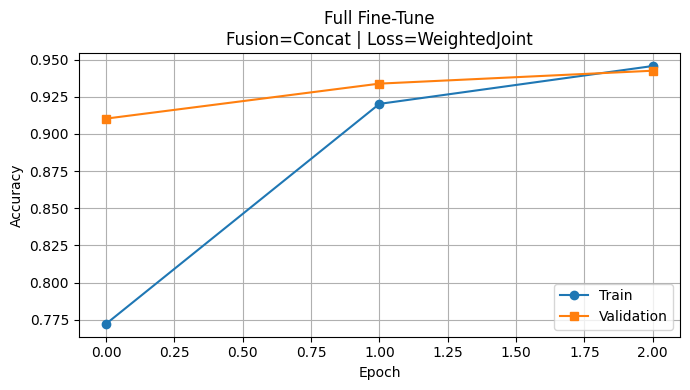

In [ ]:
def train_finetune_epoch(model, loader, optimizer):
    model.train()
    correct = total = 0

    for batch in tqdm(loader, desc="FineTune"):
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits, img_feat, text_feat = model(
            images,
            input_ids,
            attention_mask,
            return_embeddings=True
        )

        loss = compute_loss(
            best_loss,
            logits,
            labels,
            img_feat,
            text_feat
        )

        loss.backward()
        optimizer.step()

        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return correct / total


@torch.no_grad()
def validate_finetune(model, loader):
    model.eval()
    correct = total = 0

    for batch in loader:
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits, _, _ = model(
            images,
            input_ids,
            attention_mask,
            return_embeddings=True
        )

        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return correct / total


# --------------------------------------------------
# Best configuration from previous experiments
# --------------------------------------------------

best_fusion = "Concat"
best_loss = "WeightedJoint"

print("\nFull Fine-Tune")
print(f"  Fusion : {best_fusion}")
print(f"  Loss   : {best_loss}")
print("  Frozen : False (all layers trainable)\n")


# --------------------------------------------------
# Create fresh model
# --------------------------------------------------

set_seed()

full_model = FusionModel(
    num_classes=NUM_CLASSES,
    fusion_type=best_fusion,
    proj_dim=PROJ_DIM,
    freeze_backbones=False
).to(device)


# --------------------------------------------------
# Differential learning rates
# --------------------------------------------------

optimizer = torch.optim.AdamW([
    {
        "params": full_model.image_backbone.parameters(),
        "lr": 1e-5
    },
    {
        "params": full_model.text_backbone.parameters(),
        "lr": 1e-5
    },
    {
        "params": full_model.image_proj.parameters(),
        "lr": 1e-4
    },
    {
        "params": full_model.text_proj.parameters(),
        "lr": 1e-4
    },
    {
        "params": full_model.classifier.parameters(),
        "lr": 1e-4
    }
], weight_decay=1e-4)


# --------------------------------------------------
# Training
# --------------------------------------------------

finetune_hist = {
    "train": [],
    "val": []
}

best_val = 0.0
best_state = None

for epoch in range(EPOCHS):

    tr_acc = train_finetune_epoch(
        full_model,
        train_loader,
        optimizer
    )

    vl_acc = validate_finetune(
        full_model,
        val_loader
    )

    finetune_hist["train"].append(tr_acc)
    finetune_hist["val"].append(vl_acc)

    # Save best validation model
    if vl_acc > best_val:
        best_val = vl_acc
        best_state = {
            k: v.cpu().clone()
            for k, v in full_model.state_dict().items()
        }

    print(
        f"[FullFineTune | {best_fusion} + {best_loss}] "
        f"Epoch {epoch+1}/{EPOCHS} "
        f"| Train {tr_acc:.4f} "
        f"| Val {vl_acc:.4f}"
    )


# --------------------------------------------------
# Restore best epoch
# --------------------------------------------------

full_model.load_state_dict(best_state)

print("\n" + "=" * 60)
print("FULL FINE-TUNING COMPLETE")
print("=" * 60)
print(f"Best Fusion       : {best_fusion}")
print(f"Best Loss         : {best_loss}")
print(f"Best Val Accuracy : {best_val:.4f}")
print("=" * 60)


# --------------------------------------------------
# Accuracy plot
# --------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(
    finetune_hist["train"],
    label="Train",
    marker="o"
)

plt.plot(
    finetune_hist["val"],
    label="Validation",
    marker="s"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    f"Full Fine-Tune\n"
    f"Fusion={best_fusion} | Loss={best_loss}"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
@torch.no_grad()
def evaluate_final(model, loader, split="Validation"):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        images         = batch["image"].to(device)
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)
        logits, _, _   = model(
            images, input_ids, attention_mask,
            return_embeddings=True
        )
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    print(f"\n{'='*60}")
    print(f" Final Evaluation — {split} Set")
    print(f"{'='*60}")
    print(classification_report(
        all_labels, all_preds,
        labels=list(range(NUM_CLASSES)),
        target_names=[id2label[i] for i in range(NUM_CLASSES)],
        zero_division=0
    ))


evaluate_final(full_model, val_loader,  "Validation")
evaluate_final(full_model, test_loader, "Test")


 Final Evaluation — Validation Set
                        precision    recall  f1-score   support

    Accessory Gift Set       1.00      1.00      1.00        22
             Backpacks       0.96      0.99      0.97       143
                Bangle       0.94      0.94      0.94        17
             Bath Robe       1.00      1.00      1.00         4
                 Belts       1.00      1.00      1.00       162
                Boxers       0.92      1.00      0.96        11
                   Bra       1.00      1.00      1.00        95
              Bracelet       0.92      0.92      0.92        13
                Briefs       1.00      0.98      0.99       169
             Camisoles       1.00      1.00      1.00         8
                Capris       0.84      0.91      0.88        35
                  Caps       1.00      0.98      0.99        56
          Casual Shoes       0.89      0.87      0.88       568
              Churidar       0.86      1.00      0.92         6
   

In [ ]:
test_image_paths   = [os.path.join(IMAGE_DIR, r)
                      for r in test_df[IMG_COL].tolist()]
test_texts_list    = test_df[TEXT_COL].tolist()
test_label_tensor  = torch.tensor(
    [label2id[l] for l in test_df[LABEL_COL].tolist()]
)


@torch.no_grad()
def extract_embeddings(model, loader):
    model.eval()
    img_embs, txt_embs = [], []
    for batch in tqdm(loader, desc="Extracting"):
        images         = batch["image"].to(device)
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        _, img_feat, text_feat = model(
            images, input_ids, attention_mask,
            return_embeddings=True
        )
        img_embs.append(F.normalize(img_feat,  dim=1).cpu())
        txt_embs.append(F.normalize(text_feat, dim=1).cpu())
    return torch.cat(img_embs), torch.cat(txt_embs)


img_embeds, txt_embeds = extract_embeddings(
    full_model, test_loader
)
print("Image embeddings:", img_embeds.shape)
print("Text  embeddings:", txt_embeds.shape)

temperature       = 0.07
similarity_matrix = (txt_embeds @ img_embeds.T) / temperature
print("Similarity matrix:", similarity_matrix.shape)

Extracting: 100%|██████████| 278/278 [01:40<00:00,  2.76it/s]


Image embeddings: torch.Size([8886, 512])
Text  embeddings: torch.Size([8886, 512])
Similarity matrix: torch.Size([8886, 8886])


In [ ]:
def recall_at_k(sim_matrix, labels, k):
    correct = 0
    for i in range(sim_matrix.shape[0]):
        topk = torch.topk(sim_matrix[i], k).indices
        if labels[i] in labels[topk]:
            correct += 1
    return correct / sim_matrix.shape[0]


print("\nText → Image Retrieval")
for k in [1, 5, 10]:
    r = recall_at_k(
        similarity_matrix, test_label_tensor, k
    )
    print(f"  Recall@{k}: {r:.4f}")

print("\nImage → Text Retrieval")
for k in [1, 5, 10]:
    r = recall_at_k(
        similarity_matrix.T, test_label_tensor, k
    )
    print(f"  Recall@{k}: {r:.4f}")


Text → Image Retrieval
  Recall@1: 0.8165
  Recall@5: 0.8935
  Recall@10: 0.9148

Image → Text Retrieval
  Recall@1: 0.6993
  Recall@5: 0.8725
  Recall@10: 0.9151



Query : 'formal shoes'


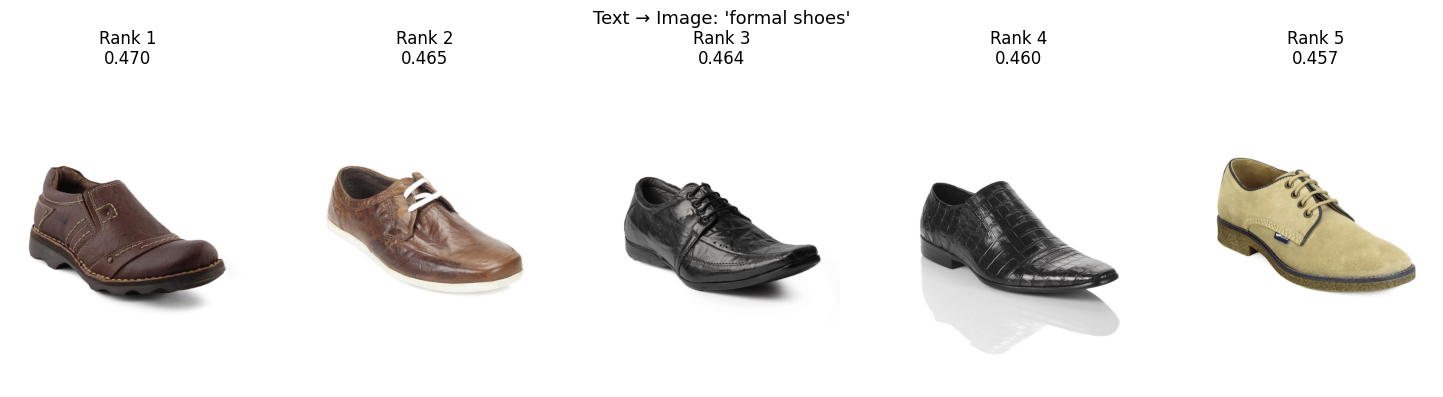


Query : 'casual summer dress'


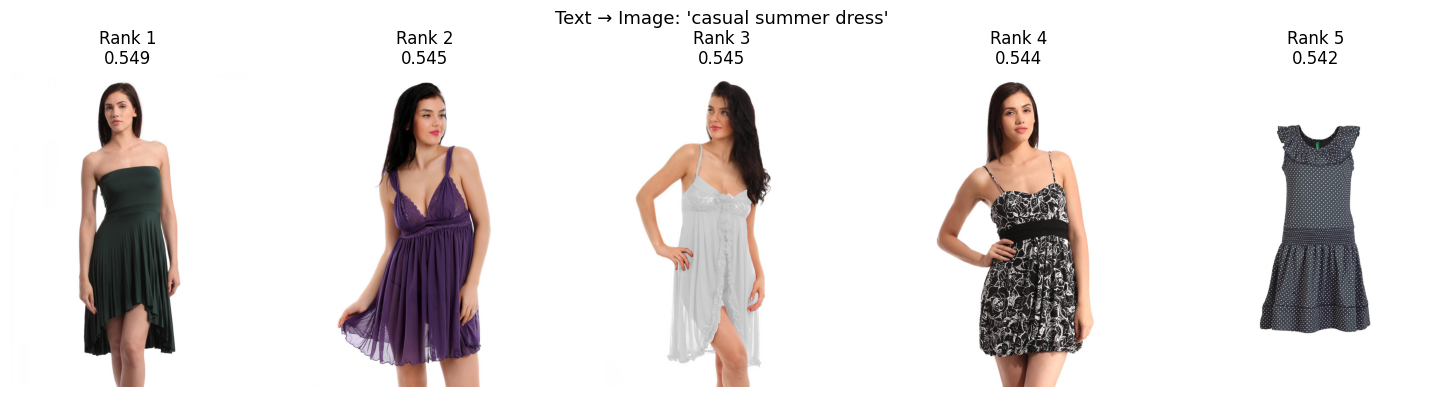


Query : 'blue denim jacket'


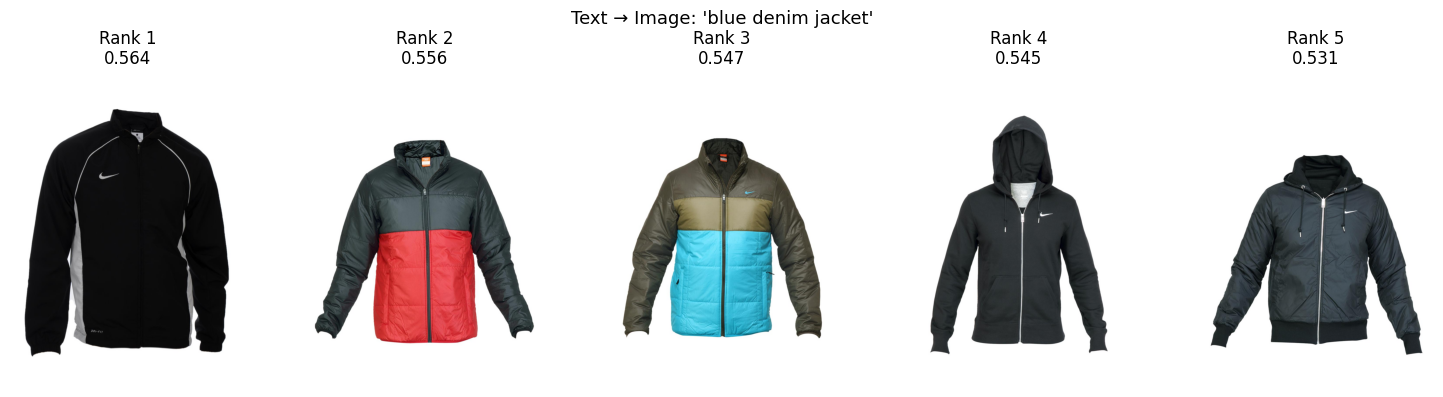

In [ ]:
@torch.no_grad()
def encode_query(query_text):
    tokens    = tokenizer(
        query_text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    ).to(device)
    cls       = full_model.text_backbone(
        input_ids=tokens["input_ids"],
        attention_mask=tokens["attention_mask"]
    ).last_hidden_state[:, 0]
    text_feat = full_model.text_proj(cls)
    return F.normalize(text_feat, dim=1).cpu()


def search_images(query_text, top_k=5):
    q_emb = encode_query(query_text)
    sims  = q_emb @ img_embeds.T
    topk  = torch.topk(sims[0], top_k)
    print(f"\nQuery : '{query_text}'\n{'='*50}")
    plt.figure(figsize=(15, 4))
    for i, (idx, score) in enumerate(
            zip(topk.indices, topk.values)):
        img = Image.open(
            test_image_paths[idx]
        ).convert("RGB")
        plt.subplot(1, top_k, i + 1)
        plt.imshow(img)
        plt.title(f"Rank {i+1}\n{score:.3f}")
        plt.axis("off")
    plt.suptitle(
        f"Text → Image: '{query_text}'", fontsize=13
    )
    plt.tight_layout(); plt.show()


# Run demo queries
search_images("formal shoes")
search_images("casual summer dress")
search_images("blue denim jacket")

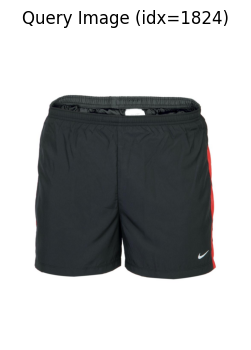


Top 5 Matching Descriptions
Rank 1 | Score 7.518
Composition Yellow three quarter length trousers made of 100% cotton, has belt loops at the waistband and an elasticated back, a hook and zipper closure, two insert pockets on the sides, two patch pockets on the back with embroidered detailing, brand name embroidered on the left leg and a zipper pocket on the right leg  Fit Regular  Wash care Machine wash separately in cold water using a mild detergent Do not bleach or soak Line dry inside out in shade Warm iron only Do not iron directly on print/embroidery  boys will love these three quarter length trousers from Gini and Jony. The elasticated waistband gives a great fit, while the cotton fabric keeps him feeling fresh and comfortable all day. Team them with tees and comfy footwear for a stylish, casual look.

Rank 2 | Score 7.481
Composition Blue denim three quarter length trousers made of 100% cotton, has belt loops at the waistband and an elasticated back, a hook and zipper closure, 

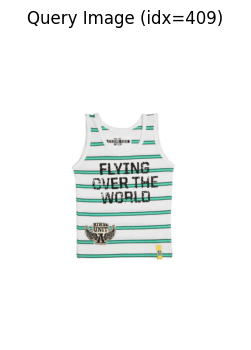


Top 5 Matching Descriptions
Rank 1 | Score 5.516
Composition: 100% cotton white baby Daisy top Washcare: Machine wash in cold water with a gentle cycle using mild detergent. Wash dark colours seperately. Do not bleach. Do not soak nor wring. Dry it inside out. Do not tumble dry. Do not iron on print and studs. Fitting: Comfort Fit Enhance that mischievous glint in your little girl's eyes with this white top from disney. It has a Daisy print and blue ruffle detailing on the chest that gives it a girly look. Team this with shorts or jeans when you take her out for an active day in the park.

Rank 2 | Score 5.502
Composition Yellow t-shirt with round neck and bold print across the front, made of 100% cotton Wash care 1. Machine wash separately in cold water 2. Use mild detergent 3. Do not bleach 4. Avoid soaking 5. Line dry inside out in shade 6. Warm iron only 7. Do not iron directly on print Fitting Regular Jet set into your little ones getting all fashionable and stylish in casual wea

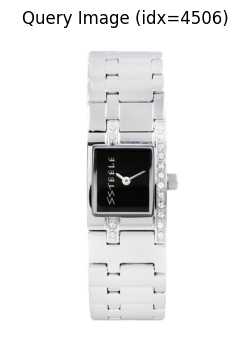


Top 5 Matching Descriptions
Rank 1 | Score 6.405
adidas' sporty white resin strap Cambridge chronograph wrist watch makes it easy to offset any outfit. The stone embellished bezel and ever-stylish white pops against any colour outfit with ease. Strap it on and seize the day! Case diameter: 40 mm Case thickness: 10 mm Dial shape: Round Silver case with a white plastic strap for enhanced durability and comfort Tang clasp to keep the watch firm in place as a belt buckle Fixed resin bezel for added durability Chronograph system where time is counted and accumulated in various formats independent of the main time, like displaying date, month, seconds, a stop watch, etc. Quartz movement of time display to ensure accurate time measurement Scratch resistant mineral crystal to keep your watch safe and well protected for years Solid case back for enhanced life Water resistant at 50 meters allowing you to use it when washing the car or in rain

Rank 2 | Score 6.404
Product description This adida

In [ ]:
def image_to_text_demo(index, top_k=5):
    img = Image.open(
        test_image_paths[index]
    ).convert("RGB")
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Query Image (idx={index})")
    plt.axis("off")
    plt.show()

    sims = similarity_matrix.T[index]
    topk = torch.topk(sims, top_k)

    print(f"\nTop {top_k} Matching Descriptions")
    print("="*50)
    for rank, (idx, score) in enumerate(
            zip(topk.indices, topk.values)):
        print(f"Rank {rank+1} | Score {score:.3f}")
        print(test_texts_list[idx])
        print()


# Run on a few random test images
for _ in range(3):
    image_to_text_demo(
        random.randint(0, len(test_image_paths) - 1)
    )